In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('/home/bitbug/Documents/Shell/environmental factors.csv')

In [4]:
df.head()

,temperature,humidity,wind_speed,carbon_emissions,solar_irradiance,pollution_level
0,22.490802,52.418449,19.599966,337.165056,369.020837,84.723658
1,34.014286,49.974726,8.690240,256.681604,185.335998,49.451704
2,29.639879,40.569235,11.932794,484.024336,213.723302,19.546561
3,26.973170,66.436000,18.265613,148.540303,262.604015,73.664179
4,18.120373,58.597450,14.641787,314.535387,283.288001,41.867814


In [5]:
df.isnull().sum()

temperature         0
humidity            0
wind_speed          0
carbon_emissions    0
solar_irradiance    0
pollution_level     0
dtype: int64

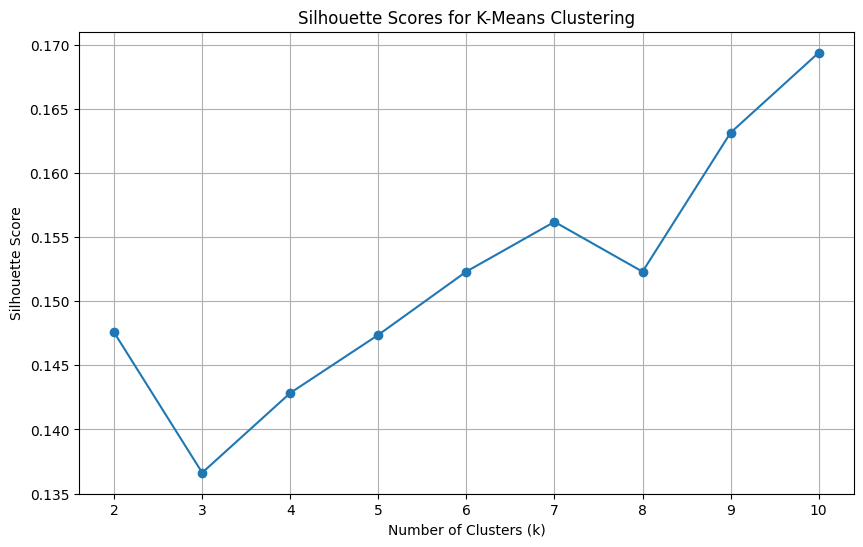

Optimal number of clusters: 10


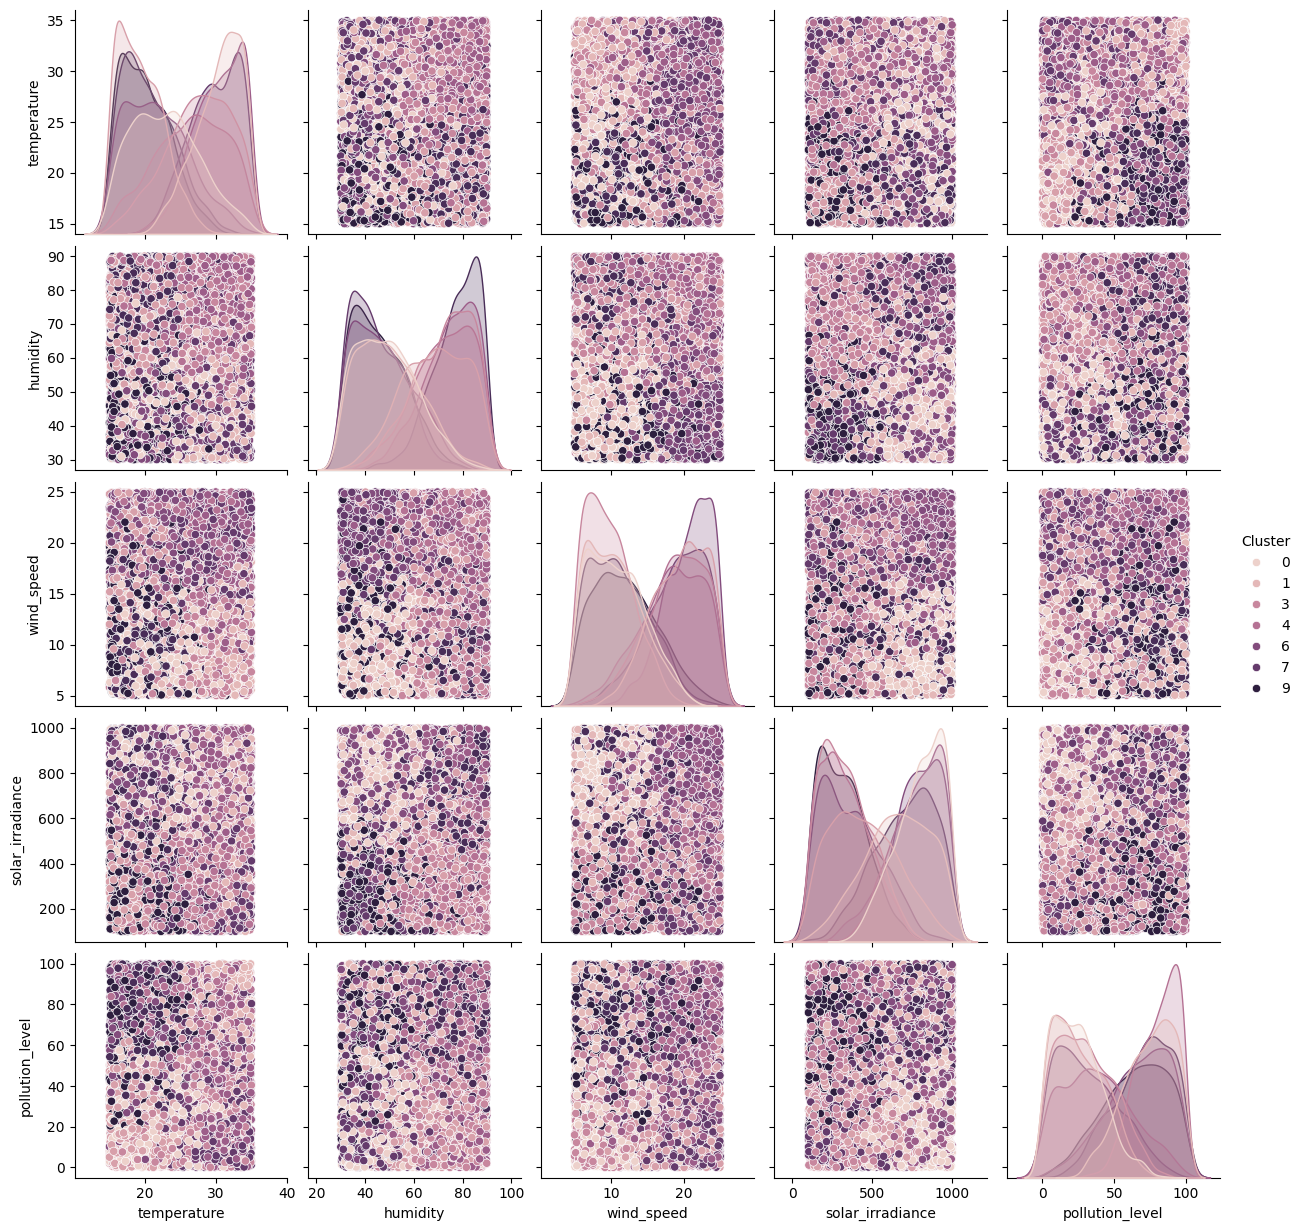

         temperature   humidity  ...  solar_irradiance  pollution_level
Cluster                          ...                                   
0          22.897952  49.036989  ...        793.359102        24.488488
1          30.326841  49.986212  ...        654.144049        74.106547
2          19.385346  68.275884  ...        445.093699        25.532913
3          27.499861  71.981965  ...        336.335007        30.039843
4          26.389889  71.989185  ...        326.368288        79.853467
5          30.221944  74.478237  ...        780.462755        38.292461
6          21.762523  47.441780  ...        763.176276        66.496196
7          29.692516  44.918900  ...        366.445335        31.708452
8          20.519071  77.209540  ...        699.106125        69.888559
9          20.072446  45.908769  ...        317.694044        64.368399

[10 rows x 6 columns]


In [8]:
data = df.drop('carbon_emissions', axis=1)  
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
k_values = range(2, 11)
silhouette_scores = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(scaled_data)
    silhouette_avg = silhouette_score(scaled_data, cluster_labels)
    silhouette_scores.append(silhouette_avg)
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Scores for K-Means Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid()
plt.show()
optimal_k = k_values[np.argmax(silhouette_scores)]
print(f'Optimal number of clusters: {optimal_k}')
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)
sns.pairplot(df, hue='Cluster', vars=data.columns)
plt.show()
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)


In [9]:
sil_score = silhouette_score(scaled_data, df['Cluster'])
print(f'Silhouette Score for the clustering: {sil_score}')

Silhouette Score for the clustering: 0.16936732172221697
